<center><font size=10>Covid-19 Image Classification</center></font>

<center><p float="center">
  <img src="https://api.parashospitals.com/uploads/2020/03/FoodProductsCOVID19_1600x900_0.jpg" width="920"/>
</p></center>

# **Introduction**

COVID-19 is an infectious respiratory disease caused by the SARS-CoV-2 virus. Early detection is important for timely treatment and reducing the spread of the disease. Chest X-ray images can help identify lung infections, and deep learning techniques such as Convolutional Neural Networks (CNNs) can automatically classify these images. In this project, a CNN model is developed to classify chest X-ray images into COVID-19 and Normal categories.

# **Problem Statement**

Manual analysis of chest X-ray images is time-consuming and requires experienced radiologists. The aim of this project is to build a CNN model that can automatically classify chest X-ray images as COVID-19 or Normal with good accuracy.

# **Objectives**

* Build a CNN model for COVID-19 detection.
* Preprocess chest X-ray images.
* Compare different CNN models.
* Evaluate model performance.
* Predict COVID-19 using unseen X-ray images

# **Data Description**

The dataset contains chest X-ray images belonging to two classes: COVID-19 and Normal. All images are resized to 128 × 128 pixels before training the model.

# **Expected Outcome**

The project aims to develop a CNN model that accurately classifies chest X-ray images and assists in the early detection of COVID-19.

#**Importing the Necessary Libraries**


We import libraries to use ready-made functions, save time, and make coding easier.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



import cv2

from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


# **Analysis:**
We import TensorFlow to build the CNN model and set a random seed so that the program produces the same results every time it is executed.

In [2]:
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# **Loading The Data**


Mount the Google Drive


We use this code to connect Google Drive with Google Colab. After connecting, we can easily access our dataset, images, and project files stored in Google Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




Load the CovidImages.npy file and store it as images.


We use this code to load the chest X-ray image dataset into the program for training the CNN model.

In [4]:

images = np.load('/content/drive/MyDrive/GEN-AI/CovidImages .npy')


Load the CovidLabels.csv file and store it as labels.

In [5]:

labels = pd.read_csv('/content/drive/MyDrive/GEN-AI/CovidLabels.csv')

# **Data Overview**

Data Overview means understanding the basic information about the dataset before building the model.



Display the number of rows and columns in the images.

In [6]:
print(images.shape)

(251, 128, 128, 3)


* Total Number of Images: We have 251 individual images.

* Dimensions of Each Image: Each image is 128 pixels wide and 128 pixels tall.

* Number of Channels: Each image has 3 color channels, typically representing Red, Green, and Blue (RGB).





Display the 5th image from the dataset

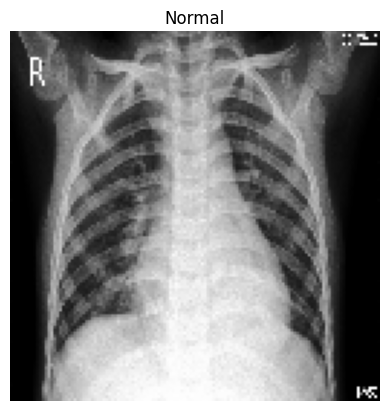

In [7]:
plt.imshow(images[5])
plt.title(labels.iloc[5, 0])
plt.axis('off')
plt.show()

# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is the process of exploring and understanding the dataset before training the model.



Visualize 12 images from different labels in a 3×4 grid layout.

In [ ]:

plt.figure(figsize=(12, 9))
for i in range(12):
  plt.subplot(3,4, i+1)
  plt.imshow(images[i*20])
  plt.title(labels.iloc[i*20, 0])
  plt.axis('off')
plt.tight_layout()
plt.show()



Visualize the proportion of each label in the labels dataset

In [ ]:

plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=labels, palette='viridis')
plt.title('Proportion of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# **Data Preprocessing**





Data Preprocessing means preparing the dataset before training the model.



Map the Labels dataset with Covid as 1 and Normal as 0

In [ ]:
labels['Label'] = labels['Label'].map({'Covid': 1, 'Normal': 0})



Split the data into training, validation, and test sets in a 70:15:15 ratio

In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(images, labels['Label'], test_size=0.3, random_state=42, stratify=labels['Label'])

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

# **Data Normalization**

Data normalization is the process of converting pixel values from 0–255 to 0–1. This helps the CNN model train faster and improves its performance.



Normalize the image data.

In [ ]:

X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print(f"Normalized training set min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")
print(f"Normalized validation set min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")
print(f"Normalized test set min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")


# **Model Building**



Create an empty DataFrame evaluation_result to store the model name along with train accuracy, validation accuracy, train recall for COVID, and validation recall for COVID.

In [ ]:
evaluation_result = pd.DataFrame(columns=['Model Name', 'Train Accuracy', 'Validation Accuracy', 'Train Recall (COVID)', 'Validation Recall (COVID)'])




Reset any previously stored Keras model state and release system memory.

# **CNN Model 1**

We clear the previous model and remove unused memory to free RAM and improve the model's performance.

In [ ]:
import gc

tf.keras.backend.clear_session()

gc.collect()



Create a Convolutional neural network model for binary class image classification with the following architecture:

An input layer
3 Combination of Convolutional and Pooling Layer
1 hidden layer and ReLU activation
An output layer
Use a relevant loss function, Adam as the optimizer, and accuracy as the metric to optimize for. Show the final model architecture with number of parameters and other details.

In [ ]:

model_cnn1 = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam()
model_cnn1.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_cnn1.summary()



Fit the model on the training data for 10 epochs with a batch size of 8, and record the training time.



In [ ]:

import time

start_time = time.time()

history = model_cnn1.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")



Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

In [ ]:

train_loss, train_acc = model_cnn1.evaluate(X_train_normalized, y_train, verbose=0)

val_loss, val_acc = model_cnn1.evaluate(X_val_normalized, y_val, verbose=0)

y_train_pred_prob = model_cnn1.predict(X_train_normalized)
y_val_pred_prob = model_cnn1.predict(X_val_normalized)

y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (3 Conv Layers)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)


print("Evaluation Results:")
evaluation_result

# **Observation:**

* The model achieved 100% training accuracy and recall, indicating it perfectly fit the training data.
* Validation accuracy was 97.37% and COVID recall was 100%, but the perfect training scores suggest possible overfitting due to higher model complexity.

# **CNN Model 2**

* Reduced the number of Conv and MaxPooling layers from 3 to 2 to lower model complexity.
* Decreased the learning rate of the optimizer to 0.0001 for more stable and controlled training.
* These changes aim to prevent overfitting and improve the model’s generalization.



Reset any previously stored Keras model state and release system memory.

In [ ]:
import gc


tf.keras.backend.clear_session()

gc.collect()



Create Convolutional neural network model for binary class image classification with the following architecture:
* An input layer
* 2 Combination of Convolutional and Pooling Layer
* 1 hidden layer with ReLU activation
* An output layer with 1 class

In [ ]:
model_cnn2 = Sequential([

    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2], X_train_normalized.shape[3])),

    Conv2D(32, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(64,activation='relu'),

    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)

model_cnn2.compile(optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_cnn2.summary()



Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.

In [ ]:

import time

start_time = time.time()

history = model_cnn2.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")



Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

In [ ]:

train_loss, train_acc = model_cnn2.evaluate(X_train_normalized, y_train, verbose=0)

val_loss, val_acc = model_cnn2.evaluate(X_val_normalized, y_val, verbose=0)

y_train_pred_prob = model_cnn2.predict(X_train_normalized)
y_val_pred_prob = model_cnn2.predict(X_val_normalized)

y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (2 Conv Layer)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

print("Evaluation Results:")
evaluation_result

# **Observation:**

* The model achieved 96% training accuracy and 97.37% validation accuracy, with strong COVID recall on validation (94.1%), indicating effective classification.
* Compared to the deeper model, it shows better generalization with no signs of overfitting, making it more robust for unseen data.
* Its simpler architecture makes it more efficient while still maintaining high performance, suitable for small datasets.

# **Model Performance Comparison and Final Model Selection**

* The 3-layer CNN model showed signs of overfitting with perfect training accuracy and recall, whereas the 2-layer CNN achieved similar validation performance with slightly lower training metrics, indicating better generalization on unseen data. Hence, we consider the 2-layer CNN (Model 2) as our final model.

| Feature                 | CNN Model 1 | CNN Model 2         |
| ----------------------- | ----------- | ------------------- |
| Conv Layers             | 3           | 2                   |
| Training Accuracy       | **100%**    | **96%**             |
| Validation Accuracy     | **97.37%**  | **97.37%**          |
| COVID Validation Recall | **100%**    | **94.12%**          |
| Complexity              | High        | Low                 |
| Overfitting             | Yes         | No (or very little) |
| Generalization          | Poor        | Better              |
| Final Choice            |   No        |   Yes               |


# **Observation:**

The final 2-layer CNN model achieved a test accuracy of 97.37% and a COVID recall of 94.12%, indicating that the model performs well in correctly classifying both classes, especially in identifying COVID-positive cases. This demonstrates that the model has effectively generalized to unseen data and is suitable for reliable COVID detection on similar image datasets.

# **Prediction for unseen data**

**Prediction Using The Test Data**

In [ ]:
index = 5

plt.imshow(X_test[index])

plt.show()

prediction = model_cnn2.predict(X_test_normalized[index].reshape(1,128,128,3))

if prediction > 0.5:
    print("COVID")
else:
    print("NORMAL")

print("Actual:", y_test.iloc[index])


**Prediction Using the new covid affected Image**

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

image = cv2.imread("image-corona notebook.jpg")

plt.imshow(image)
plt.show()

image = cv2.resize(image, (128,128))
image = image / 255.0
image = image.reshape(1,128,128,3)

prediction = model_cnn2.predict(image)
if prediction[0][0] > 0.5:
    print("COVID")
else:
    print("NORMAL")

# **Conclusion**

* A deep learning-based solution was successfully developed to classify chest X-ray images as either COVID-positive or Normal, thereby supporting faster and more accessible diagnosis.

* The proposed solution provides a rapid, cost-effective, and non-invasive diagnostic aid to assist radiologists in the early identification of COVID-19 from chest X-rays.

* Future improvements may include expanding the dataset with a larger and more diverse set of images to further enhance the model’s robustness and generalizability.